# Store Sales Analysis
## Exploratory Data Analysis
* **Goal:** Understand the structure, quality and charachteristics of the dataset.

In [124]:
# Import libraries 

import pandas as pd 
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [125]:
# Define path to data folder

data_path = Path('../data')
data_path

PosixPath('../data')

In [126]:
# Find all csv in the folder

files = list(data_path.glob('*.csv'))
files

[PosixPath('../data/test.csv'),
 PosixPath('../data/train.csv'),
 PosixPath('../data/transactions.csv'),
 PosixPath('../data/oil.csv'),
 PosixPath('../data/holidays_events.csv'),
 PosixPath('../data/sample_submission.csv'),
 PosixPath('../data/stores.csv')]

In [127]:
# Create dictionary for all files

dataframes = {}

for file in files:
    name = file.stem
    dataframes[name] = pd.read_csv(file)

In [128]:
# Check dictionary

dataframes.keys()

dict_keys(['test', 'train', 'transactions', 'oil', 'holidays_events', 'sample_submission', 'stores'])

In [129]:
dataframes['train'].head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [130]:
# Check shape of all dataframes

for name, df in dataframes.items():
    print(name, df.shape)

test (28512, 5)
train (3000888, 6)
transactions (83488, 3)
oil (1218, 2)
holidays_events (350, 6)
sample_submission (28512, 2)
stores (54, 5)


In [131]:
# Check missing values for all dataframes

for name, df in dataframes.items():
    print('-'*30)
    print(name)
    print(df.isna().sum())

------------------------------
test
id             0
date           0
store_nbr      0
family         0
onpromotion    0
dtype: int64
------------------------------
train
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64
------------------------------
transactions
date            0
store_nbr       0
transactions    0
dtype: int64
------------------------------
oil
date           0
dcoilwtico    43
dtype: int64
------------------------------
holidays_events
date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64
------------------------------
sample_submission
id       0
sales    0
dtype: int64
------------------------------
stores
store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64


In [132]:
# Inspect missing values in oil dataframe

dataframes['oil'][dataframes['oil']['dcoilwtico'].isna()]

,date,dcoilwtico
0,2013-01-01,NaN
14,2013-01-21,NaN
34,2013-02-18,NaN
63,2013-03-29,NaN
104,2013-05-27,NaN
132,2013-07-04,NaN
174,2013-09-02,NaN
237,2013-11-28,NaN
256,2013-12-25,NaN
261,2014-01-01,NaN


In [133]:
dataframes['oil'].head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


### Data Quality Check

The automated data quality check showed that most datasets contain no missing values. The `oil` dataset contains 43 missing values in `dcoilwtico`. These missing values occur on specific dates, mainly holidays and non-trading days, so they are not necessarily errors. Further investigation is needed before deciding how to handle them.

In [134]:
# Check dtype for all dataframes

for name, df in dataframes.items():
    print('-'*30)
    print(name)
    print(df.dtypes)
    print()

------------------------------
test
id              int64
date           object
store_nbr       int64
family         object
onpromotion     int64
dtype: object

------------------------------
train
id               int64
date            object
store_nbr        int64
family          object
sales          float64
onpromotion      int64
dtype: object

------------------------------
transactions
date            object
store_nbr        int64
transactions     int64
dtype: object

------------------------------
oil
date           object
dcoilwtico    float64
dtype: object

------------------------------
holidays_events
date           object
type           object
locale         object
locale_name    object
description    object
transferred      bool
dtype: object

------------------------------
sample_submission
id         int64
sales    float64
dtype: object

------------------------------
stores
store_nbr     int64
city         object
state        object
type         object
cluster       int

In [135]:
# Convert all date objects columns into datetime

for name, df in dataframes.items():
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])

In [136]:
# Check columns tolist

for name, df in dataframes.items():
    print('-'*30)
    print(name)
    print(df.columns.tolist())

------------------------------
test
['id', 'date', 'store_nbr', 'family', 'onpromotion']
------------------------------
train
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']
------------------------------
transactions
['date', 'store_nbr', 'transactions']
------------------------------
oil
['date', 'dcoilwtico']
------------------------------
holidays_events
['date', 'type', 'locale', 'locale_name', 'description', 'transferred']
------------------------------
sample_submission
['id', 'sales']
------------------------------
stores
['store_nbr', 'city', 'state', 'type', 'cluster']


In [137]:
# Check nunique for stores_nbr
dataframes['stores']['store_nbr'].nunique()

54

In [138]:
# Check nunique for stores_nbr
dataframes['train']['store_nbr'].nunique()

54

In [139]:
# Check len of stres
len(dataframes['stores'])

54

In [140]:
# Check if there is information in train set which are not in store
set(dataframes['train']['store_nbr']) - set(dataframes['stores']['store_nbr'])

set()

In [141]:
set(dataframes['stores']['store_nbr']) - set(dataframes['train']['store_nbr'])

set()

In [142]:
# Merge train dataset with store dataset

train = dataframes['train'].merge(
    dataframes['stores'], 
    on='store_nbr',
    how='left'
)

In [143]:
# Check shape of new dataset
print(f'Rows:{train.shape[0]} -- Columns:{train.shape[1]}')

Rows:3000888 -- Columns:10


In [144]:
# Check head
train.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13


In [145]:
# Check missing values
train.isna().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
city           0
state          0
type           0
cluster        0
dtype: int64

In [146]:
# Check head of transactions df
dataframes['transactions'].head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [147]:
dataframes['transactions'].duplicated(
    subset=['date', 'store_nbr']
).sum()

np.int64(0)

In [148]:
train_keys = set(zip(train['date'], train['store_nbr']))
transaction_keys = set(
    zip(
        dataframes['transactions']['date'],
        dataframes['transactions']['store_nbr']
    )
)
len(train_keys-transaction_keys)

7448

In [149]:
missing_keys = train_keys - transaction_keys
list(missing_keys)[:10]

[(Timestamp('2015-07-04 00:00:00'), 42),
 (Timestamp('2013-04-05 00:00:00'), 20),
 (Timestamp('2014-11-27 00:00:00'), 42),
 (Timestamp('2014-10-10 00:00:00'), 52),
 (Timestamp('2013-01-18 00:00:00'), 20),
 (Timestamp('2013-10-17 00:00:00'), 22),
 (Timestamp('2013-06-15 00:00:00'), 42),
 (Timestamp('2014-03-15 00:00:00'), 20),
 (Timestamp('2013-04-03 00:00:00'), 42),
 (Timestamp('2015-07-19 00:00:00'), 22)]

In [150]:
missing_dates = [date for date, store in missing_keys]
pd.Series(missing_dates).value_counts().head(10)

2016-01-03    54
2016-01-01    54
2015-01-01    53
2017-01-01    53
2013-01-01    53
2014-01-01    52
2016-01-04    40
2016-01-02    18
2013-06-19    11
2013-04-21     8
Name: count, dtype: int64

In [151]:
pd.Series(missing_dates).dt.day_name().value_counts()

Sunday       1112
Tuesday      1072
Wednesday    1065
Friday       1061
Thursday     1058
Monday       1055
Saturday     1025
Name: count, dtype: int64

In [152]:
pd.Series(missing_dates).nunique()

1566

In [153]:
dataframes["transactions"]["date"].min(), dataframes["transactions"]["date"].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

In [154]:
pd.Series(
    [store for date, store in missing_keys]
).value_counts().head(10)

52    1566
22    1013
42     964
21     936
29     810
20     775
53     517
36     133
18     118
24     107
Name: count, dtype: int64

In [155]:
# Merge with transaction
train = train.merge(
    dataframes['transactions'],
    on=['date', 'store_nbr'], 
    how='left'
)

In [156]:
# Check missing values
train.isna().sum()

id                   0
date                 0
store_nbr            0
family               0
sales                0
onpromotion          0
city                 0
state                0
type                 0
cluster              0
transactions    245784
dtype: int64

In [157]:
# Check missing values
train[train['transactions'].isna()][['date', 'store_nbr', 'transactions']].head(20)

,date,store_nbr,transactions
0,2013-01-01,1,NaN
1,2013-01-01,1,NaN
2,2013-01-01,1,NaN
3,2013-01-01,1,NaN
4,2013-01-01,1,NaN
5,2013-01-01,1,NaN
6,2013-01-01,1,NaN
7,2013-01-01,1,NaN
8,2013-01-01,1,NaN
9,2013-01-01,1,NaN


In [158]:
dataframes["holidays_events"][
    dataframes["holidays_events"]["date"] == "2013-01-01"
]

,date,type,locale,locale_name,description,transferred
41,2013-01-01,Holiday,National,Ecuador,Primer dia del ano,False


In [159]:
# Check missing dates 
missing_dates = pd.Series(missing_dates).drop_duplicates()

In [160]:
missing_dates.isin(
    dataframes['holidays_events']['date']
).sum()

np.int64(235)

In [161]:
pd.Series(missing_dates).agg(['min', 'max'])

min   2013-01-01
max   2017-04-19
dtype: datetime64[ns]

In [162]:
train["transactions"].isna().mean() * 100

np.float64(8.190375648807953)

In [163]:
# Check total sum of missing transactions
train['transactions'].isna().sum()

np.int64(245784)

In [164]:
missing_transaction = train[train['transactions'].isna()]

In [165]:
missing_with_holidays = missing_transaction.merge(
    dataframes['holidays_events'], 
    on='date', 
    how='left'
)

In [166]:
missing_with_holidays.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,type_y,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,Primer dia del ano,False
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,Primer dia del ano,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,Primer dia del ano,False
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,Primer dia del ano,False


In [167]:
# Check missing transaction on holidays
missing_with_holidays['type_y'].value_counts(dropna=False)

type_y
NaN           205656
Holiday        31218
Event           5544
Additional      4653
Work Day         990
Transfer         594
Bridge           462
Name: count, dtype: int64

In [168]:
missing_with_holidays['locale'].value_counts(dropna=False)

locale
NaN         205656
National     25773
Local        15279
Regional      2409
Name: count, dtype: int64

In [169]:
missing_with_holidays[missing_with_holidays['locale'] == 'National']['type_y'].value_counts()

type_y
Holiday       14586
Event          5544
Additional     3663
Work Day        990
Transfer        528
Bridge          462
Name: count, dtype: int64

In [170]:
national_holidays = missing_with_holidays[
    (missing_with_holidays['locale'] == 'National') &
    (missing_with_holidays['type_y'] == 'Holiday')
]

In [171]:
national_holidays[['date', 'description', 'transferred']].drop_duplicates()

,date,description,transferred
0,2013-01-01,Primer dia del ano,False
12309,2013-02-11,Carnaval,False
12573,2013-02-12,Carnaval,False
32637,2013-04-29,Viernes Santo,False
33165,2013-05-01,Dia del Trabajo,False
38973,2013-05-24,Batalla de Pichincha,False
58575,2013-08-10,Primer Grito de Independencia,False
72435,2013-10-09,Independencia de Guayaquil,True
77979,2013-11-02,Dia de Difuntos,False
78210,2013-11-03,Independencia de Cuenca,False


In [172]:
national_holidays['date'].nunique()

44

In [173]:
national_holidays['transferred'].value_counts()

transferred
False    12342
True      2244
Name: count, dtype: int64

In [174]:
national_holidays[
    ['date', 'description', 'transferred']
].drop_duplicates(subset=['date'])

,date,description,transferred
0,2013-01-01,Primer dia del ano,False
12309,2013-02-11,Carnaval,False
12573,2013-02-12,Carnaval,False
32637,2013-04-29,Viernes Santo,False
33165,2013-05-01,Dia del Trabajo,False
38973,2013-05-24,Batalla de Pichincha,False
58575,2013-08-10,Primer Grito de Independencia,False
72435,2013-10-09,Independencia de Guayaquil,True
77979,2013-11-02,Dia de Difuntos,False
78210,2013-11-03,Independencia de Cuenca,False


In [175]:
national_holidays[
    national_holidays['transferred'] == True
][['date', 'description']].drop_duplicates(subset=['date'])

,date,description
72435,2013-10-09,Independencia de Guayaquil
159423,2014-10-09,Independencia de Guayaquil
230241,2016-05-24,Batalla de Pichincha
232947,2016-08-10,Primer Grito de Independencia
243771,2017-01-01,Primer dia del ano


In [176]:
normal_national_holidays = national_holidays[
    national_holidays['transferred'] == False
]

In [177]:
normal_national_holidays['date'].nunique()

39

In [178]:
normal_national_holidays.groupby('date')['store_nbr'].nunique()

date
2013-01-01    53
2013-02-11     8
2013-02-12     8
2013-04-29     8
2013-05-01     8
2013-05-24     7
2013-08-10     7
2013-11-02     7
2013-11-03     7
2014-01-01    52
2014-03-03     7
2014-03-04     7
2014-04-18     8
2014-05-01     8
2014-05-24     8
2014-08-10     7
2014-11-02     6
2014-11-03     6
2015-01-01    53
2015-02-16     5
2015-02-17     5
2015-04-03     5
2015-05-01     5
2015-05-24     5
2015-08-10     3
2015-10-09     1
2015-11-02     1
2015-11-03     1
2016-01-01    54
2016-02-08     1
2016-02-09     1
2016-03-25     1
2016-05-01     1
2016-10-09     3
2016-11-02     2
2016-11-03     2
2017-02-27     1
2017-02-28     1
2017-04-14     1
Name: store_nbr, dtype: int64

In [179]:
normal_national_holidays[
    normal_national_holidays['date'] == '2013-02-11'
][['date', 'store_nbr', 'city', 'state', 'type_x']]

,date,store_nbr,city,state,type_x
12309,2013-02-11,20,Quito,Pichincha,B
12310,2013-02-11,20,Quito,Pichincha,B
12311,2013-02-11,20,Quito,Pichincha,B
12312,2013-02-11,20,Quito,Pichincha,B
12313,2013-02-11,20,Quito,Pichincha,B
...,...,...,...,...,...
12568,2013-02-11,53,Manta,Manabi,D
12569,2013-02-11,53,Manta,Manabi,D
12570,2013-02-11,53,Manta,Manabi,D
12571,2013-02-11,53,Manta,Manabi,D


In [180]:
normal_national_holidays[
    normal_national_holidays['date'] == '2013-02-11'
]['store_nbr'].nunique()

8

In [181]:
normal_national_holidays[
    normal_national_holidays['date'] == '2013-02-11'
][['date', 'store_nbr', 'city', 'state', 'type_x']].drop_duplicates(
    subset=['date', 'store_nbr']
)

,date,store_nbr,city,state,type_x
12309,2013-02-11,20,Quito,Pichincha,B
12342,2013-02-11,21,Santo Domingo,Santo Domingo de los Tsachilas,B
12375,2013-02-11,22,Puyo,Pastaza,C
12408,2013-02-11,29,Guayaquil,Guayas,E
12441,2013-02-11,36,Libertad,Guayas,E
12474,2013-02-11,42,Cuenca,Azuay,D
12507,2013-02-11,52,Manta,Manabi,A
12540,2013-02-11,53,Manta,Manabi,D


### Data Quality Check – Summary

The initial data quality check identified missing values in two datasets.

- **Oil dataset:** 43 missing values in `dcoilwtico`. These occur on specific dates, including holidays and non-trading days. Further investigation may be required during preprocessing.
- **Transactions dataset:** After merging transactions with the training data, 245,784 rows (8.19%) contained missing transaction values. These correspond to 7,448 unique store-date combinations.
- **National holidays:** Some missing transaction values occur on national holidays. However, the affected stores vary in location and store type, and not all missing values can be explained by holidays.

Missing transaction values will not automatically be replaced with zero, as missing data does not necessarily indicate that a store was closed.

Further investigation and appropriate handling of missing values will be considered during the preprocessing stage.

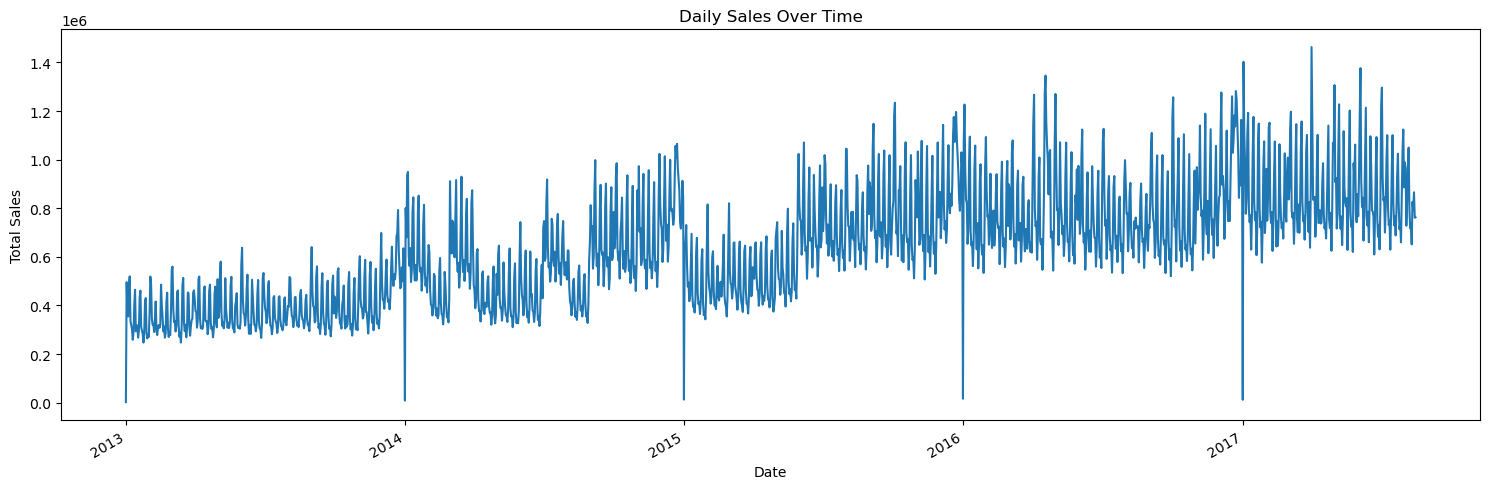

In [182]:
# Calculate the sales per day

daily_sales = train.groupby('date')['sales'].sum()

# Plot Sales per Day

daily_sales.plot(figsize=(15, 5))
plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

### Sales Over Time – Initial Findings

The daily sales trend shows an overall increase in sales over the observed period, with fluctuations from day to day.

A recurring pattern can be observed on January 1st, when sales drop to zero each year. This may indicate that stores are closed on New Year's Day.

Overall, the data suggests a gradual upward trend in sales over time.